**MAIN GOAL** : Cluster loyal versus disengaged customers by behavioral and financial 
attributes. Mine rules such as: customers from Germany holding only one 
product who are inactive represent a strong churn profile. Detect anomalies 
in sudden balance drops preceding account closure.


# Phase 1 : Data Understanding and Preprocessing


P1 Goal : Produce a clean, analysis-ready dataset and document every preprocessing 
decision with justification. This phase establishes the factual foundation for all 
subsequent mining steps

## EDA

### Importing libraries and loading dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/raw/churn.csv')

### Data Types and Missing Values

In [5]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
# missing value
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Check unique values for object data

In [8]:
print( "Surname Unique counts:", df['Surname'].value_counts())


Surname Unique counts: Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64


In [9]:
print("Geography Unique counts:", df['Geography'].value_counts())

Geography Unique counts: Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [10]:
print("Gender counts:", df['Gender'].value_counts())

Gender counts: Gender
Male      5457
Female    4543
Name: count, dtype: int64


### Outlier detection

In [11]:
# Note: We identify outliers but do not drop them here, as Phase 4 
# requires cross-referencing anomalies with Phase 2 cluster outliers.

numeric_cols = df.select_dtypes(include=['number']).columns
cols_to_check = [col for col in numeric_cols if col not in ['RowNumber', 'CustomerId']]

def detect_outliers_iqr(data, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indices.extend(outliers)
        
        print(f"Column: {col} | Outliers detected: {len(outliers)}")
        
    return list(set(outlier_indices))

outlier_list = detect_outliers_iqr(df, cols_to_check)
outlier_df = df.loc[outlier_list]

Column: CreditScore | Outliers detected: 15
Column: Age | Outliers detected: 359
Column: Tenure | Outliers detected: 0
Column: Balance | Outliers detected: 0
Column: NumOfProducts | Outliers detected: 60
Column: HasCrCard | Outliers detected: 0
Column: IsActiveMember | Outliers detected: 0
Column: EstimatedSalary | Outliers detected: 0
Column: Exited | Outliers detected: 2037


### Graph Distribution of numerical features

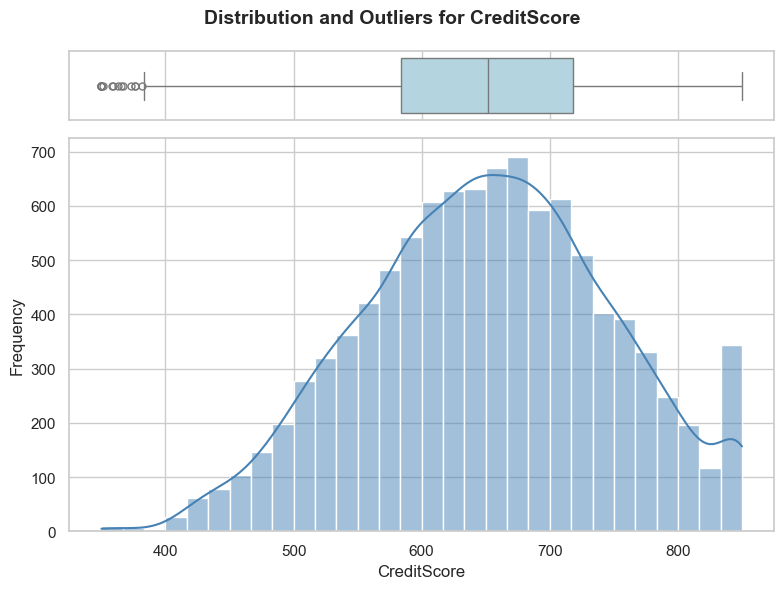

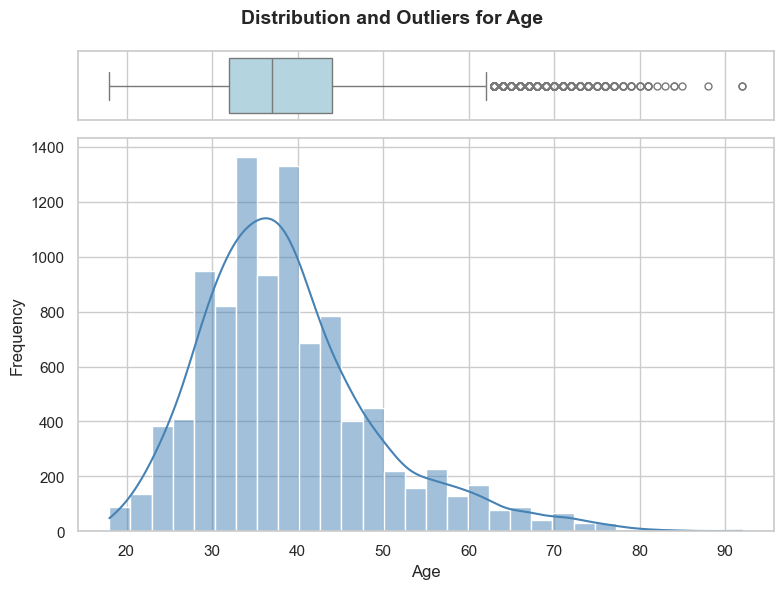

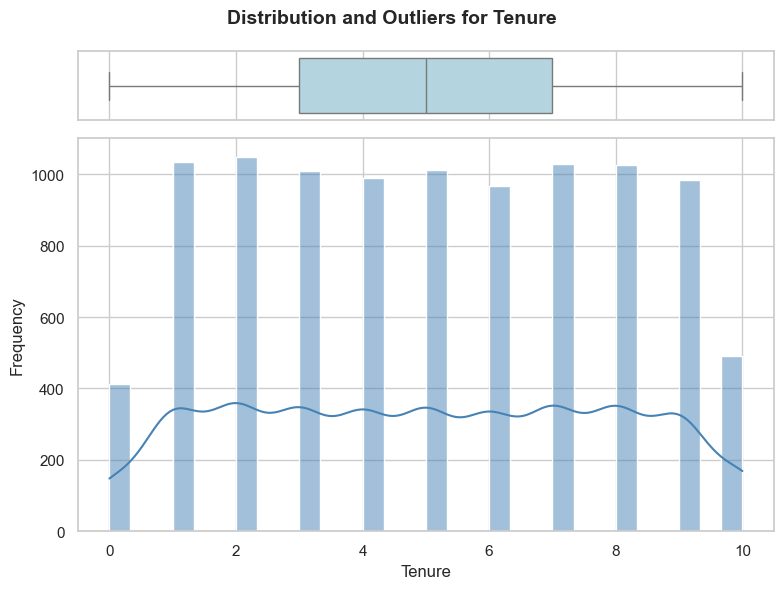

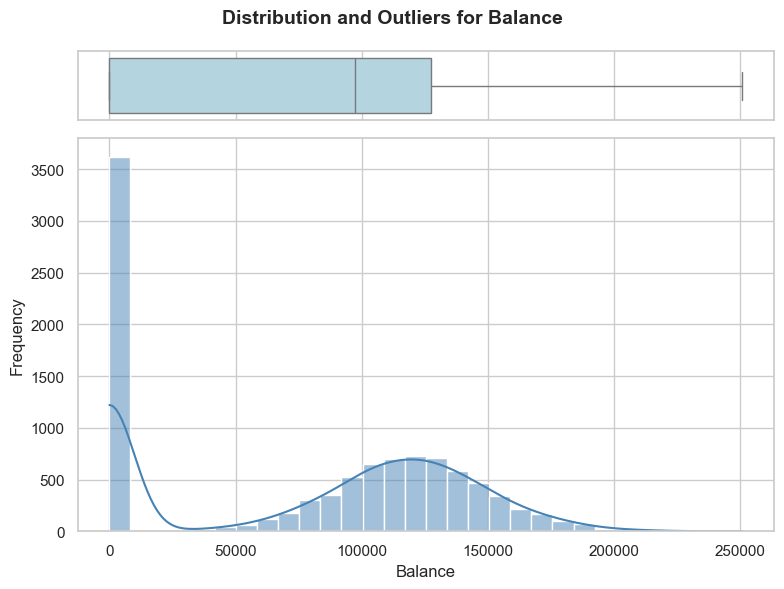

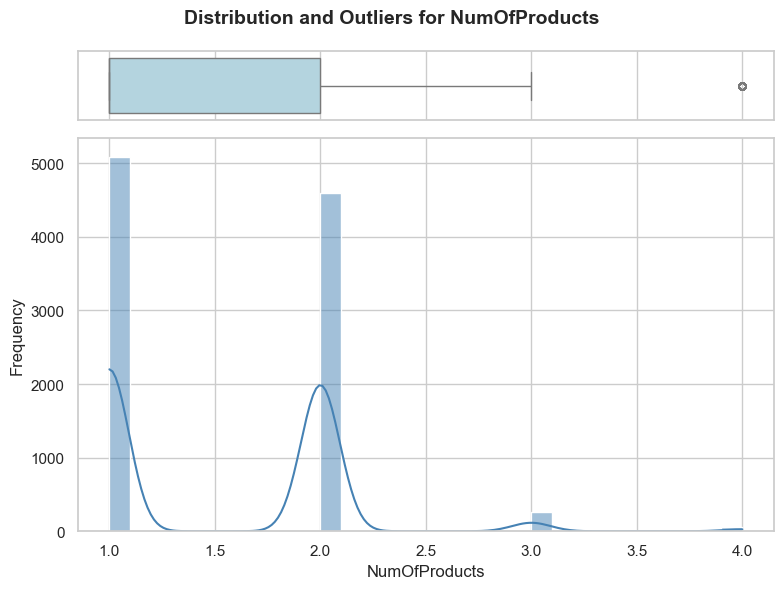

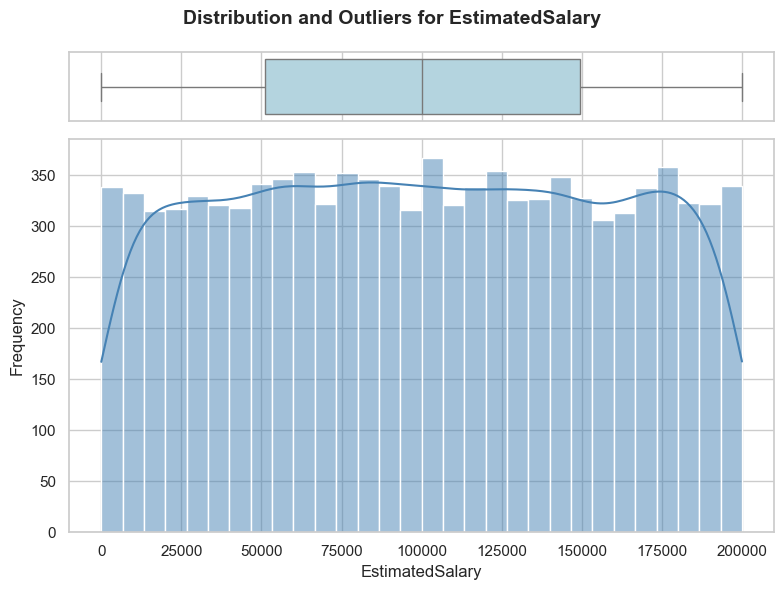

In [12]:
# 1. Define your numerical columns (excluding IDs and binary flags)
cols_to_check = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Loop through each column and create a combined graph
for col in cols_to_check:
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(8, 6))
    
    sns.boxplot(x=df[col], ax=ax_box, color='lightblue', flierprops=dict(marker='o', color='red', markersize=5))
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color='steelblue', bins=30)
    
    ax_box.set(xlabel='') 
    ax_hist.set(xlabel=col, ylabel='Frequency')
    
    plt.suptitle(f'Distribution and Outliers for {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Graph Count of object features

C:\Users\Thomas\AppData\Local\Temp\ipykernel_69280\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


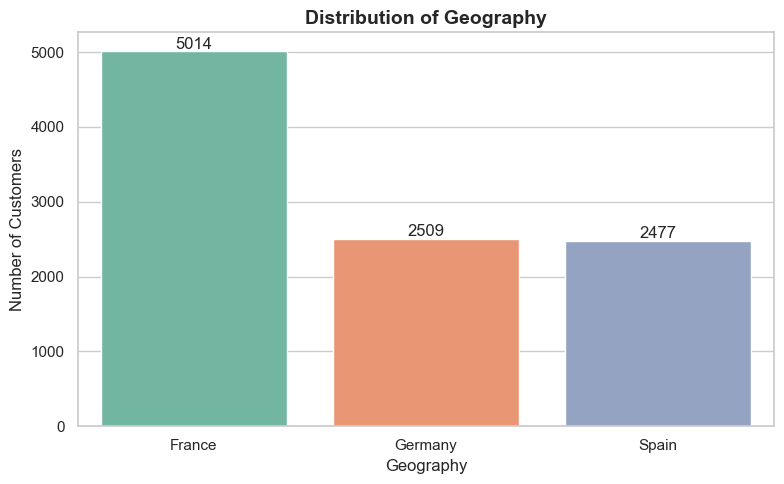

C:\Users\Thomas\AppData\Local\Temp\ipykernel_69280\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


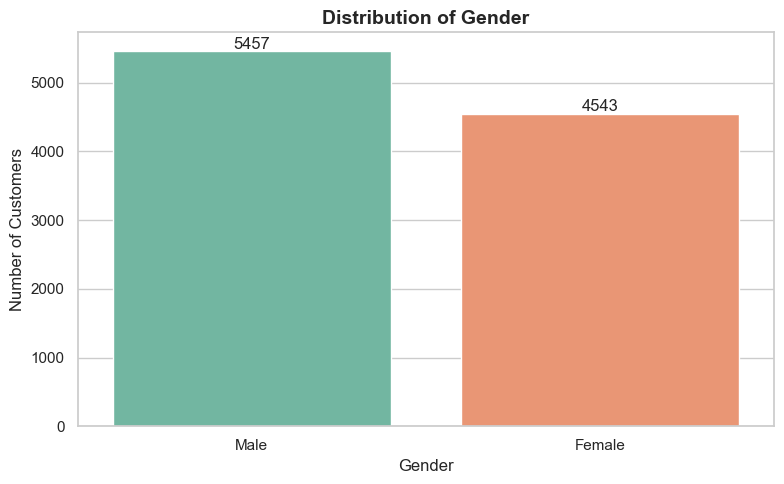

In [13]:
object_cols = df.select_dtypes(include=['object']).columns
cols_to_exclude = ['RowNumber', 'CustomerId', 'Surname']
cols_to_plot = [col for col in object_cols if col not in cols_to_exclude]

sns.set_theme(style="whitegrid")

for col in cols_to_plot:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## Apply data cleaning

In [14]:
print("Duplicates before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()

print("Missing values before cleaning:\n", df.isna().sum())
df = df.dropna()

columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print("Shape after data cleaning:", df.shape)


Duplicates before cleaning: 0
Missing values before cleaning:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Shape after data cleaning: (10000, 11)


In [15]:
zero_age_count = (df['Age'] == 0).sum()
print(f"Number of customers with Age 0: {zero_age_count}")

Number of customers with Age 0: 0


## Perform data transformation: normalization, encoding, and binning of continuous variables

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder

# 1. Binning: Creating categorical groups for Phase 3 Association Rules
if 'Age' in df.columns:
    df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 50, 60, 150], labels=['Youth', 'Adult', 'Senior', 'Elderly'])

# 2. Separate Target
X = df.drop('Exited', axis=1)
y = df['Exited']

# 3. Define Transformers
numeric_cols = ['CreditScore', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts', 'Age']
categorical_cols = ['Geography', 'AgeGroup']
binary_cols = ['Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_cols), 
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols), 
        ('bin', OrdinalEncoder(), binary_cols) 
    ],
    remainder='passthrough' 
)

# 4. Transform ENTIRE dataset (No train_test_split for unsupervised KDD)
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

X_clean = pd.DataFrame(
    pipeline.fit_transform(X), 
    columns=pipeline.get_feature_names_out()
)

print(X_clean.head())

   num__CreditScore  num__Balance  num__EstimatedSalary  num__Tenure  \
0         -0.246269     -0.761480              0.011739        -0.75   
1         -0.328358     -0.104906              0.125512        -1.00   
2         -1.119403      0.489346              0.139630         0.75   
3          0.350746     -0.761480             -0.064717        -1.00   
4          1.477612      0.221806             -0.214561        -0.75   

   num__NumOfProducts  num__Age  cat__Geography_Germany  cat__Geography_Spain  \
0                 0.0  0.416667                     0.0                   0.0   
1                 0.0  0.333333                     0.0                   1.0   
2                 2.0  0.416667                     0.0                   0.0   
3                 1.0  0.166667                     0.0                   0.0   
4                 0.0  0.500000                     0.0                   1.0   

   cat__AgeGroup_Elderly  cat__AgeGroup_Senior  cat__AgeGroup_Youth  \
0        

## Conduct feature selection using correlation analysis and entropy measures

### Heatmap of correlation between numerical features and entropy

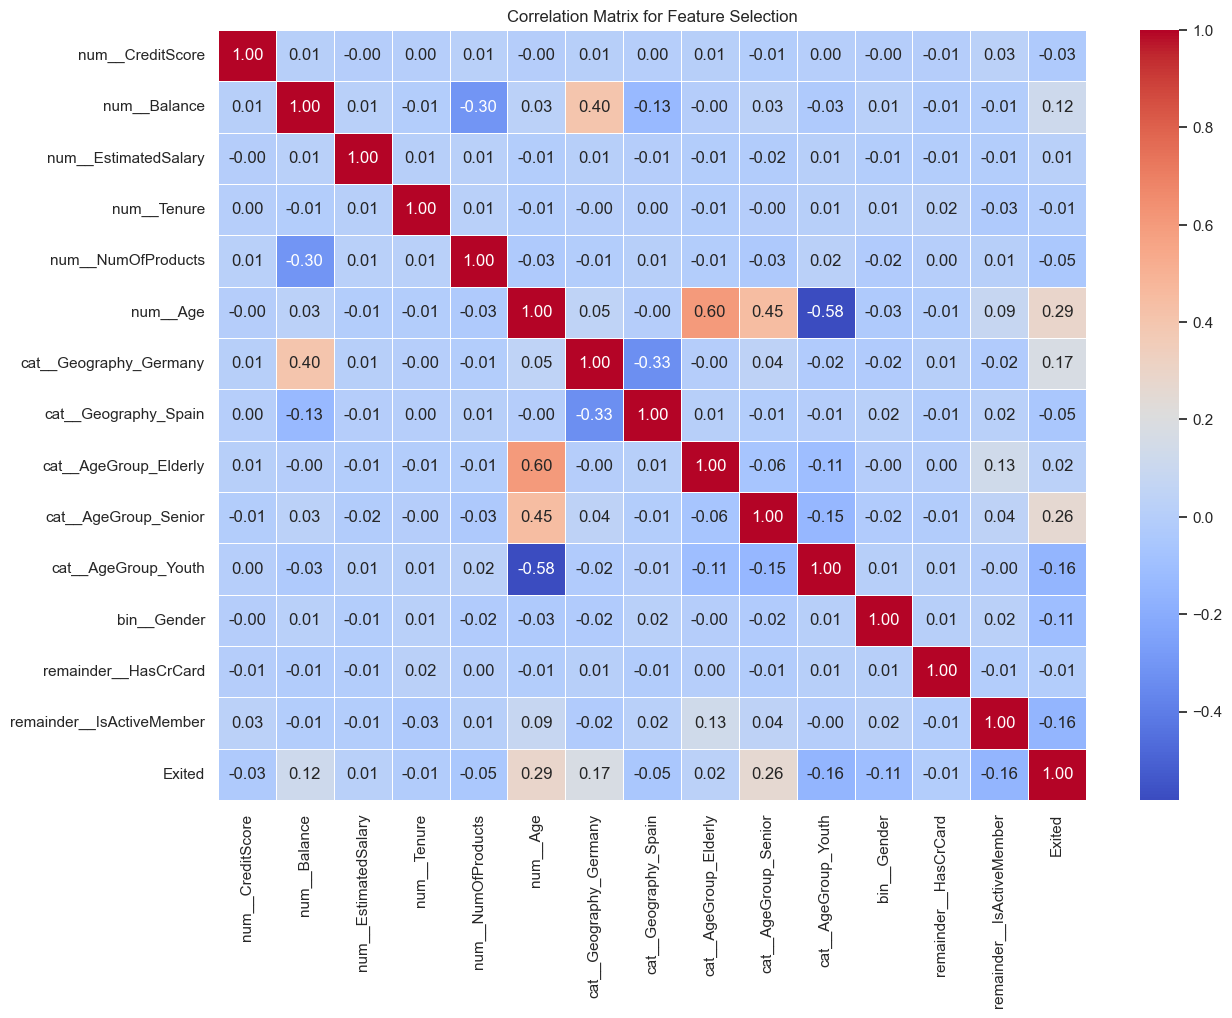


Features correlated with target ('Exited'):
 Exited                       1.000000
num__Age                     0.285323
cat__AgeGroup_Senior         0.261884
cat__Geography_Germany       0.173488
cat__AgeGroup_Youth          0.157928
remainder__IsActiveMember    0.156128
num__Balance                 0.118533
bin__Gender                  0.106512
cat__Geography_Spain         0.052667
num__NumOfProducts           0.047820
num__CreditScore             0.027094
cat__AgeGroup_Elderly        0.024178
num__Tenure                  0.014001
num__EstimatedSalary         0.012097
remainder__HasCrCard         0.007138
Name: Exited, dtype: float64

Information Gain (Entropy-based) for Feature Selection:
 num__NumOfProducts           0.075019
num__Age                     0.070925
cat__AgeGroup_Senior         0.025651
cat__AgeGroup_Youth          0.017388
cat__Geography_Germany       0.017131
remainder__IsActiveMember    0.014252
cat__AgeGroup_Elderly        0.008679
num__Balance                 0.

In [17]:
from sklearn.feature_selection import mutual_info_classif

# 1. Re-attach target for analysis
analysis_df = X_clean.copy()
analysis_df['Exited'] = y.values

# 2. Pearson Correlation
plt.figure(figsize=(14, 10))
correlation_matrix = analysis_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Feature Selection")
plt.show()

if 'Exited' in correlation_matrix.columns:
    target_corr = correlation_matrix['Exited'].abs().sort_values(ascending=False)
    print("\nFeatures correlated with target ('Exited'):\n", target_corr)
    
# 3. Entropy-based Feature Selection (Information Gain / Mutual Information)
mi_scores = mutual_info_classif(X_clean, y, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_clean.columns)
mi_scores = mi_scores.sort_values(ascending=False)

print("\nInformation Gain (Entropy-based) for Feature Selection:\n", mi_scores)

#### Checking for imbalanced in 'Exited' variable

In [18]:
# Check imbalance in Exited
df['Exited'].value_counts(normalize=True)

# 80-20 ratio, harus apply SMOTE / class weighting, isolation tree(?), ensemble method(?),
# anomaly detection, encoder(?)
# evaluation metrics yang sesuai (precision-recall, F1-score)


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## Deliverable: Clean dataset file and Preprocessing Report

In [19]:
import os

# Re-attach target variable for Phase 2 and 3
final_clean_df = X_clean.copy()
final_clean_df['Exited'] = y.values 

# Define the path relative to your notebooks/ folder
output_dir = '../data/processed/'

# Create the directory if it doesn't already exist
os.makedirs(output_dir, exist_ok=True)

# Save the single unified dataset
filepath = os.path.join(output_dir, 'churn_clean.csv')
final_clean_df.to_csv(filepath, index=False)

print(f"Phase 1 execution complete.")
print(f"Cleaned dataset saved successfully to '{filepath}'.")

Phase 1 execution complete.
Cleaned dataset saved successfully to '../data/processed/churn_clean.csv'.


# Phase 2: Segmentation via Clustering

## Apply K-Means clustering to segment entities by behavioral or financial attributes

## Use DBSCAN to identify outlier profiles and noise points within the data

## Apply Hierarchical clustering and compare dendrograms across linkage methods

## Determine optimal K using the Elbow Method and Silhouette Score

## Profile each cluster: describe the entity type it represents and its distinguishing characteristics

## Deliverable: Cluster profiles with full business interpretation

# Phase 3: Association Rule Mining

## Discretize continuous variables into meaningful categorical groups

## Apply the Apriori algorithm to discover frequent itemsets across the dataset

## Generate association rules and compute Support, Confidence, and Lift for each

## Filter rules to retain only meaningful, non-trivial, high-lift findings

## Discover and document at least 10 rules with clear business interpretation

## Deliverable: Rule table with ranked rules and business commentary

# Phase 4: Anomaly and Outlier Detection

## Apply statistical methods (IQR, Z-score) to flag anomalous behaviors or values

## Use Isolation Forest as a structural anomaly discovery tool

## Cross-reference detected anomalies with cluster outliers from Phase 2

## Investigate each anomaly: data error, rare legitimate case, or potential risk signal?

## Deliverable: Anomaly report with flagged records, explanation, and business interpretation